In [1]:
import pandas as pd
import numpy as np

import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Dataset/Zilany/Twitter- datasets.csv")

In [3]:
df.head()

,id,user_posted,name,description,date_posted,photos,url,tagged_users,replies,reposts,...,posts_count,profile_image_link,following,is_verified,quotes,bookmarks,parent_post_details,external_image_urls,videos,quoted_post
0,1868428607451799983,Glo███ews███,Glo███ews███,"Com o fim da ditadura Assad, muitos sírios con...","""2024-12-15T22:51:08.000Z""",NaN,https://x.com/GloboNews/status/186842860745179...,NaN,2,1,...,222223,https://pbs.twimg.com/profile_images/155910271...,122,False,1,1,"{""post_id"":null,""profile_id"":null,""profile_nam...",NaN,"[{""duration"":148167,""video_url"":""https://video...","{""data_posted"":null,""description"":null,""photos..."
1,1868159094567121215,bil███ard███,bil███ard███,Brian Austin Green Tells MGK to ‘Grow Up’ Afte...,"""2024-12-15T05:00:11.000Z""",NaN,https://x.com/billboard/status/186815909456712...,NaN,7,3,...,357584,https://pbs.twimg.com/profile_images/169657720...,3784,False,1,2,"{""post_id"":null,""profile_id"":null,""profile_nam...","[""https://pbs.twimg.com/card_img/1867636129563...",NaN,"{""data_posted"":null,""description"":null,""photos..."
2,1868451534708883739,TNT███rts███,TNT███ort███R,VENCE O PSG NO CLÁSSICO! 💪🇫🇷 Nossa @claalbuque...,"""2024-12-16T00:22:14.000Z""",NaN,https://x.com/TNTSportsBR/status/1868451534708...,"[{""biography"":null,""followers"":null,""following...",2,1,...,456734,https://pbs.twimg.com/profile_images/180701304...,859,False,0,1,"{""post_id"":null,""profile_id"":null,""profile_nam...",NaN,"[{""duration"":94861,""video_url"":""https://video....","{""data_posted"":null,""description"":null,""photos..."
3,1868441382022717466,TNT███rts███,TNT███ort███R,ÍDOLO E AGORA PRESIDENTE! 🇦🇷🇦🇷 O ex-atacante D...,"""2024-12-15T23:41:54.000Z""","[""https://pbs.twimg.com/media/Ge4JhOgXcAAQy5K....",https://x.com/TNTSportsBR/status/1868441382022...,"[{""biography"":null,""followers"":null,""following...",6,5,...,456734,https://pbs.twimg.com/profile_images/180701304...,859,False,1,3,"{""post_id"":null,""profile_id"":null,""profile_nam...",NaN,NaN,"{""data_posted"":null,""description"":null,""photos..."
4,1868418260892565925,Glo███ews███,Glo███ews███,.@DanielaLima_ : cirurgia de Lula travou negoc...,"""2024-12-15T22:10:01.000Z""",NaN,https://x.com/GloboNews/status/186841826089256...,"[{""biography"":null,""followers"":null,""following...",50,4,...,222223,https://pbs.twimg.com/profile_images/155910271...,122,False,3,3,"{""post_id"":null,""profile_id"":null,""profile_nam...",NaN,"[{""duration"":127067,""video_url"":""https://video...","{""data_posted"":null,""description"":null,""photos..."


In [4]:
def inspect_dataframe(df):
    print("----- DATAFRAME INFO -----")
    print(df.info(), "\n")

    print("----- DATAFRAME SHAPE -----")
    print(df.shape, "\n")

    print("----- COLUMN NAMES -----")
    print(df.columns, "\n")

    print("----- STATISTICS -----")
    print(df.describe(), "\n")

    print("----- MISSING VALUES PER COLUMN -----")
    print(df.isnull().sum(), "\n")

    print("----- TOTAL MISSING VALUES -----")
    print(df.isnull().sum().sum(), "\n")

    print("----- DATA TYPES -----")
    print(df.dtypes, "\n")

    print("----- UNIQUE VALUES PER COLUMN -----")
    print(df.nunique(), "\n")


In [5]:
inspect_dataframe(df)

----- DATAFRAME INFO -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   1000 non-null   int64 
 1   user_posted          1000 non-null   object
 2   name                 1000 non-null   object
 3   description          1000 non-null   object
 4   date_posted          1000 non-null   object
 5   photos               456 non-null    object
 6   url                  1000 non-null   object
 7   tagged_users         374 non-null    object
 8   replies              1000 non-null   int64 
 9   reposts              1000 non-null   int64 
 10  likes                1000 non-null   int64 
 11  views                1000 non-null   int64 
 12  external_url         432 non-null    object
 13  hashtags             572 non-null    object
 14  followers            1000 non-null   int64 
 15  biography            997 non-

In [6]:
df['photos'] = df['photos'].apply(lambda x: 'No' if pd.isna(x) else 'Yes')
print(df.value_counts('photos'))

photos
No     544
Yes    456
Name: count, dtype: int64


In [7]:
df['photos'] = df['photos'].map({'Yes':1, 'No':0})

In [8]:
# date & time
def extract_hour_month(df, date_column):
    # clean the datetime strings
    clean_date = (
        df[date_column]
        .astype(str)
        .str.strip()
        .str.replace('^"|"$', '', regex=True)
    )

    dt = pd.to_datetime(
        clean_date,
        format='%Y-%m-%dT%H:%M:%S.%fZ',
        utc=True,
        errors='coerce'
    )

    # hour and month
    df[f'{date_column}_hour'] = dt.dt.hour.fillna(-1).astype(int)
    df[f'{date_column}_month'] = dt.dt.month.fillna(-1).astype(int)

    return df

df = extract_hour_month(df, 'date_posted')

In [9]:
# replace nulls with empty list
df['hashtags'] = df['hashtags'].apply(lambda x: [] if pd.isna(x) else x)

df['hashtag_Y/N'] = df['hashtags'].apply(lambda x: 1 if len(x) > 0 else 0)


In [10]:
columns_to_drop = ['id', 'user_posted', 'name', 'url', 'tagged_users', 'external_url', 'biography', 'profile_image_link', 'is_verified', 'quotes',
                      'posts_count', 'parent_post_details', 'external_image_urls', 'videos', 'quoted_post', 'date_posted', 'hashtags']

df = df.drop(columns=columns_to_drop)

In [11]:
inspect_dataframe(df)

----- DATAFRAME INFO -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   description        1000 non-null   object
 1   photos             1000 non-null   int64 
 2   replies            1000 non-null   int64 
 3   reposts            1000 non-null   int64 
 4   likes              1000 non-null   int64 
 5   views              1000 non-null   int64 
 6   followers          1000 non-null   int64 
 7   following          1000 non-null   int64 
 8   bookmarks          1000 non-null   int64 
 9   date_posted_hour   1000 non-null   int64 
 10  date_posted_month  1000 non-null   int64 
 11  hashtag_Y/N        1000 non-null   int64 
dtypes: int64(11), object(1)
memory usage: 93.9+ KB
None 

----- DATAFRAME SHAPE -----
(1000, 12) 

----- COLUMN NAMES -----
Index(['description', 'photos', 'replies', 'reposts', 'likes', 'views',
       'foll

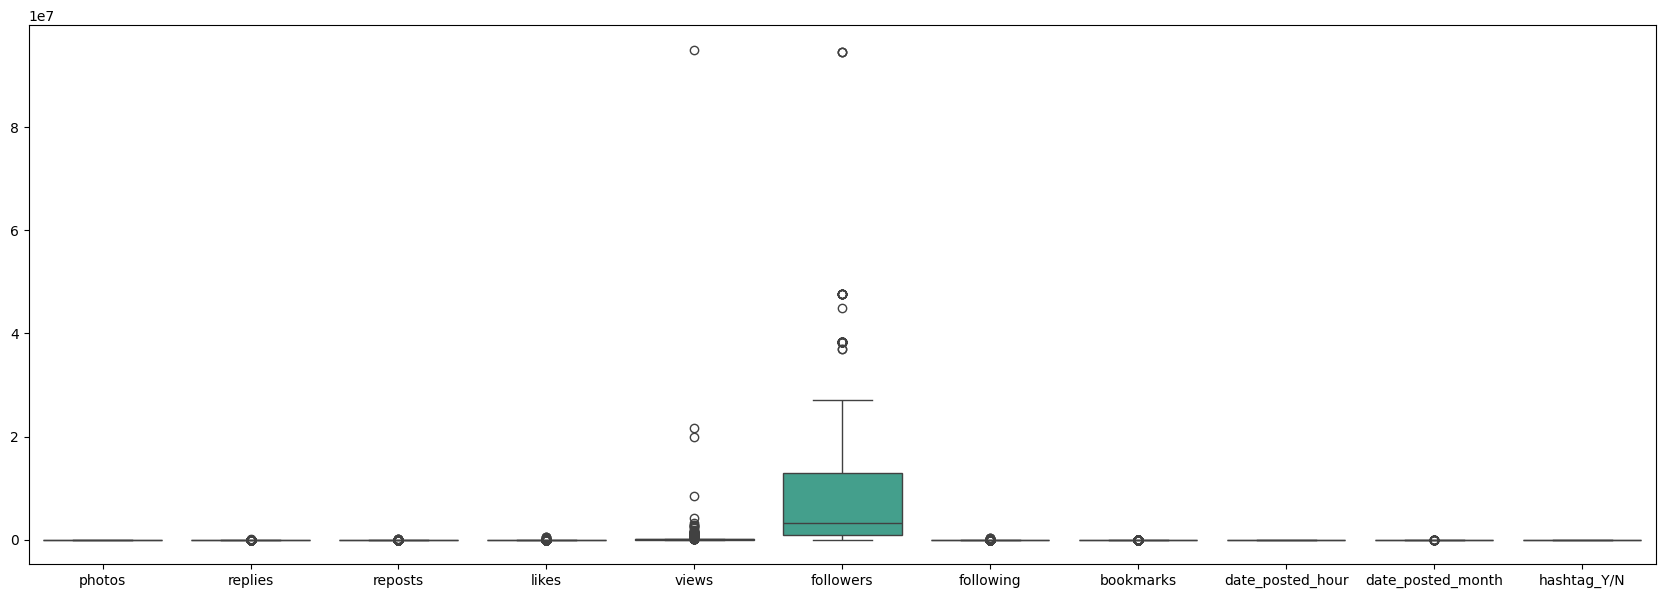

In [12]:
plt.figure(figsize=(21, 7))
sns.boxplot(data = df, orient='v')
plt.show()

In [13]:
def detect_outliers_iqr(df, drop_cols=None):
    if drop_cols is not None:
        df = df.drop(columns=drop_cols, errors='ignore')

    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    outlier_summary = []

    for col in numeric_cols:
        series = df[col].dropna()
        if series.nunique() < 2:
            continue
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        if iqr == 0:
            continue

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outliers = series[(series < lower) | (series > upper)]

        outlier_summary.append({
            'feature': col,
            'outlier_count': len(outliers),
            'outlier_percentage': round(len(outliers) / len(series) * 100, 2),
        })

    return pd.DataFrame(outlier_summary)

In [14]:
outliers = detect_outliers_iqr(
    df, drop_cols=['id', 'date_posted_hour', 'date_posted_month'])

outliers.sort_values('outlier_percentage', ascending=False)


,feature,outlier_count,outlier_percentage
6,following,159,15.9
2,reposts,153,15.3
3,likes,143,14.3
7,bookmarks,140,14.0
4,views,132,13.2
1,replies,129,12.9
5,followers,49,4.9
0,photos,0,0.0
8,hashtag_Y/N,0,0.0


In [15]:
df['engagement'] = (df['likes'] + df['reposts'] + df['replies'] + df['bookmarks'])

In [16]:
df['rich_score'] = df['engagement'] * np.log1p(df['followers'])

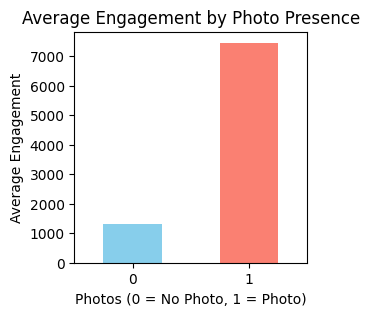

In [17]:
engagement_by_photos = df.groupby('photos')['engagement'].mean()
plt.figure(figsize=(3, 3))
engagement_by_photos.plot(kind='bar', color=['skyblue', 'salmon'])
plt.xlabel('Photos (0 = No Photo, 1 = Photo)')
plt.ylabel('Average Engagement')
plt.title('Average Engagement by Photo Presence')
plt.xticks(rotation=0)
plt.show()


In [18]:
df.groupby('hashtag_Y/N')['engagement'].mean()


,engagement
hashtag_Y/N,
0,5995.446262
1,2709.223776


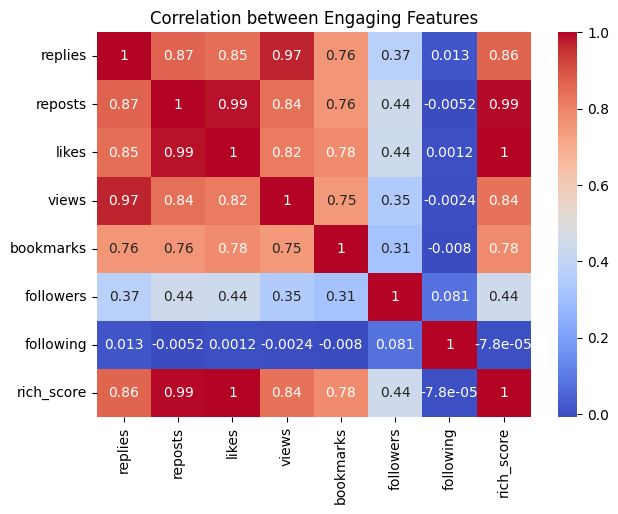

In [19]:
# Correlation heatmap
eng_cols = ['replies','reposts','likes','views','bookmarks','followers','following', 'rich_score']
plt.figure(figsize=(7,5))
sns.heatmap(df[eng_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between Engaging Features")
plt.show()


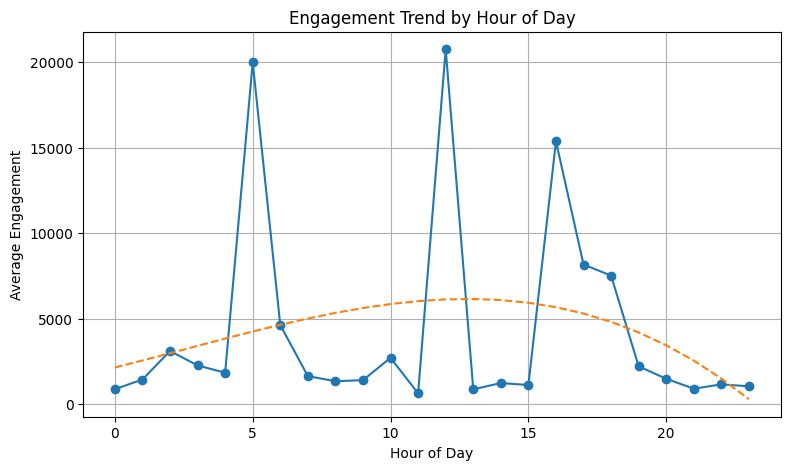

In [20]:
# average engagement per hour
hourly_engagement = df.groupby('date_posted_hour')['engagement'].mean()

plt.figure(figsize=(9, 5))
plt.plot(hourly_engagement.index, hourly_engagement.values, marker='o')
z = np.polyfit(hourly_engagement.index, hourly_engagement.values, 3)
p = np.poly1d(z)
plt.plot(hourly_engagement.index, p(hourly_engagement.index), linestyle='--')
plt.title('Engagement Trend by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Engagement')
plt.grid(True)
plt.show()


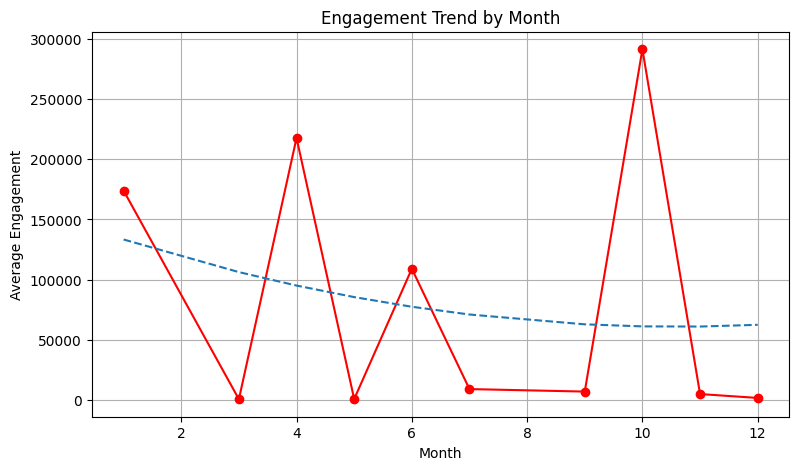

In [21]:
# average engagement per month
monthly_engagement = df.groupby('date_posted_month')['engagement'].mean()

plt.figure(figsize=(9, 5))
plt.plot(monthly_engagement.index, monthly_engagement.values, color='red', marker='o')
z = np.polyfit(monthly_engagement.index, monthly_engagement.values, 2)
p = np.poly1d(z)
plt.plot(monthly_engagement.index, p(monthly_engagement.index), linestyle='--')
plt.title('Engagement Trend by Month')
plt.xlabel('Month')
plt.ylabel('Average Engagement')
plt.grid(True)
plt.show()


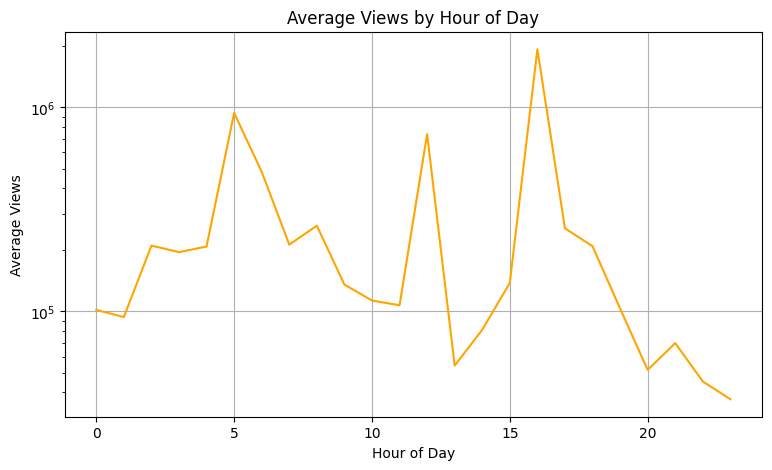

In [22]:
# avarage views per hour
hourly_views = df.groupby('date_posted_hour')['views'].mean()

plt.figure(figsize=(9, 5))
plt.plot(hourly_views.index, hourly_views.values, color='orange')
plt.title('Average Views by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Views')
plt.yscale('log')
plt.grid(True)
plt.show()


In [23]:
def fix_encoding(text):
    try:
        return text.encode('latin1').decode('utf-8')
    except:
        return text

df['description'] = df['description'].astype(str).apply(fix_encoding)

In [24]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 16.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=54ec26bf2b05778fa6e954e029db5e730060d9241e24af1c58dbeb44f74fdfaa
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [25]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0

df['lang'] = df['description'].apply(
    lambda x: detect(x) if isinstance(x, str) and x.strip() else 'unknown'
)

df = df[df['lang'] == 'en'].reset_index(drop=True)


In [26]:
df

,description,photos,replies,reposts,likes,views,followers,following,bookmarks,date_posted_hour,date_posted_month,hashtag_Y/N,engagement,rich_score,lang
0,Brian Austin Green Tells MGK to ‘Grow Up’ Afte...,0,7,3,43,25007,14257909,3784,2,5,12,0,55,906.005232,en
1,Taylor Swift’s ‘The Tortured Poets Department’...,0,9,64,524,63114,14257907,3784,9,20,12,0,606,9982.530288,en
2,Blink-182’s Tom DeLonge Shares His Theory on N...,0,4,5,19,12635,14258370,3784,1,0,12,0,29,477.712787,en
3,Taylor Swift’s Birthday Gift to Fans: A Quiet ...,0,3,7,51,14229,14257907,3784,3,23,12,0,64,1054.260625,en
4,"SEVENTEEN Talk BBMAs Performance, DJ Khaled Co...",0,6,721,1945,32803,14257909,3784,33,0,12,0,2705,44558.984588,en
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678,Your Palace in black this afternoon 🖤\n\n#CPFC...,0,58,168,928,187460,1480966,552,9,12,12,1,1163,16524.143358,en
679,This shouldn't come as a surprise!\n\n@CubSwan...,1,42,81,1341,156329,12876593,717,16,6,12,1,1480,24228.964268,en
680,HERE. WE. GO. \n\n#SNME starts RIGHT NOW on @n...,0,122,393,2579,279472,14375935,392,39,1,12,1,3133,51635.180579,en
681,Coming to the cricket...\n\nDressed as cricket...,1,15,21,764,84181,551402,282,13,9,12,1,813,10748.039850,en


In [27]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.encode('ascii', errors='ignore').decode() # unicode
    text = re.sub(r'http\S+', '', text)   # url
    text = re.sub(r'@\w+', '', text)    #mentions
    text = re.sub(r'#\w+', '', text)    # hashtags
    text = re.sub(r'\s+', ' ', text)    # whitespace
    return text.strip()

df['description_clean'] = df['description'].apply(clean_text)


In [28]:
df['post_length'] = df['description_clean'].astype(str).apply(len)

def count_words(text):
    return len(re.findall(r'\b\w+\b', text)) if isinstance(text, str) else 0

df['word_count'] = df['description_clean'].apply(count_words)


In [29]:
df

,description,photos,replies,reposts,likes,views,followers,following,bookmarks,date_posted_hour,date_posted_month,hashtag_Y/N,engagement,rich_score,lang,description_clean,post_length,word_count
0,Brian Austin Green Tells MGK to ‘Grow Up’ Afte...,0,7,3,43,25007,14257909,3784,2,5,12,0,55,906.005232,en,Brian Austin Green Tells MGK to Grow Up After ...,91,16
1,Taylor Swift’s ‘The Tortured Poets Department’...,0,9,64,524,63114,14257907,3784,9,20,12,0,606,9982.530288,en,Taylor Swifts The Tortured Poets Department Lo...,84,15
2,Blink-182’s Tom DeLonge Shares His Theory on N...,0,4,5,19,12635,14258370,3784,1,0,12,0,29,477.712787,en,Blink-182s Tom DeLonge Shares His Theory on Ne...,70,12
3,Taylor Swift’s Birthday Gift to Fans: A Quiet ...,0,3,7,51,14229,14257907,3784,3,23,12,0,64,1054.260625,en,Taylor Swifts Birthday Gift to Fans: A Quiet R...,86,15
4,"SEVENTEEN Talk BBMAs Performance, DJ Khaled Co...",0,6,721,1945,32803,14257909,3784,33,0,12,0,2705,44558.984588,en,"SEVENTEEN Talk BBMAs Performance, DJ Khaled Co...",91,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678,Your Palace in black this afternoon 🖤\n\n#CPFC...,0,58,168,928,187460,1480966,552,9,12,12,1,1163,16524.143358,en,Your Palace in black this afternoon //,38,6
679,This shouldn't come as a surprise!\n\n@CubSwan...,1,42,81,1341,156329,12876593,717,16,6,12,1,1480,24228.964268,en,This shouldn't come as a surprise! &amp; are t...,83,15
680,HERE. WE. GO. \n\n#SNME starts RIGHT NOW on @n...,0,122,393,2579,279472,14375935,392,39,1,12,1,3133,51635.180579,en,HERE. WE. GO. starts RIGHT NOW on and !!!,41,8
681,Coming to the cricket...\n\nDressed as cricket...,1,15,21,764,84181,551402,282,13,9,12,1,813,10748.039850,en,Coming to the cricket... Dressed as crickets,44,7


In [30]:
cols_to_drop = ['description', 'replies', 'reposts', 'likes', 'engagement', 'rich_score', 'lang',]

df = df.drop(columns=cols_to_drop)

In [31]:
df

,photos,views,followers,following,bookmarks,date_posted_hour,date_posted_month,hashtag_Y/N,description_clean,post_length,word_count
0,0,25007,14257909,3784,2,5,12,0,Brian Austin Green Tells MGK to Grow Up After ...,91,16
1,0,63114,14257907,3784,9,20,12,0,Taylor Swifts The Tortured Poets Department Lo...,84,15
2,0,12635,14258370,3784,1,0,12,0,Blink-182s Tom DeLonge Shares His Theory on Ne...,70,12
3,0,14229,14257907,3784,3,23,12,0,Taylor Swifts Birthday Gift to Fans: A Quiet R...,86,15
4,0,32803,14257909,3784,33,0,12,0,"SEVENTEEN Talk BBMAs Performance, DJ Khaled Co...",91,13
...,...,...,...,...,...,...,...,...,...,...,...
678,0,187460,1480966,552,9,12,12,1,Your Palace in black this afternoon //,38,6
679,1,156329,12876593,717,16,6,12,1,This shouldn't come as a surprise! &amp; are t...,83,15
680,0,279472,14375935,392,39,1,12,1,HERE. WE. GO. starts RIGHT NOW on and !!!,41,8
681,1,84181,551402,282,13,9,12,1,Coming to the cricket... Dressed as crickets,44,7


In [32]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    df['description_clean'].tolist(),
    batch_size=32,
    show_progress_bar=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

In [33]:
num_cols = ['followers', 'following', 'bookmarks', 'date_posted_hour', 'date_posted_month', 'post_length', 'word_count']

bin_cols = ['photos', 'hashtag_Y/N']

In [34]:
X_num = df[num_cols].values
X_bin = df[bin_cols].values
X_text = embeddings

In [35]:
y = np.log1p(df['views'].values)

In [36]:
from sklearn.model_selection import train_test_split

X_text_train, X_text_test, \
X_num_train, X_num_test, \
X_bin_train, X_bin_test, \
y_train, y_test = train_test_split(
    X_text, X_num, X_bin, y,
    test_size=0.2,
    random_state=42)

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)


In [38]:
X_train = np.hstack([X_text_train, X_num_train_scaled, X_bin_train])

X_test = np.hstack([X_text_test, X_num_test_scaled, X_bin_test])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (546, 393)
Test shape: (137, 393)


In [39]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=0
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [40]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MSE:", rmse)
print("R²:", r2)

MSE: 0.574194264103654
R²: 0.7827149537537252


In [41]:
# predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

from sklearn.metrics import r2_score

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Train R²:", r2_train)
print("Test R²:", r2_test)

Train R²: 0.997987193775082
Test R²: 0.7827149537537252


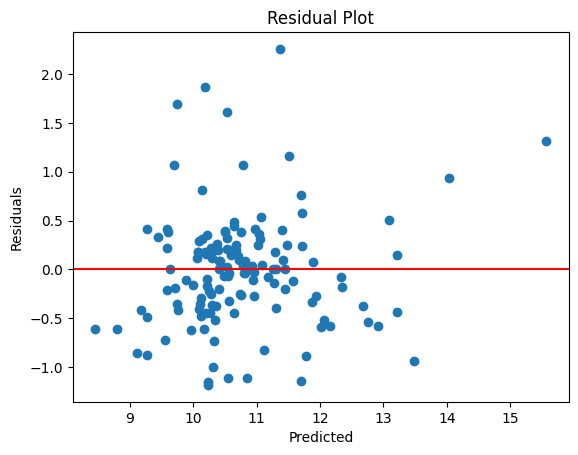

In [42]:
import matplotlib.pyplot as plt

plt.scatter(y_test_pred, y_test - y_test_pred)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [43]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

ridge_model = Ridge(alpha=10.0, random_state=0)

ridge_model.fit(X_train, y_train)

# predictions
y_train_pred_ridge = ridge_model.predict(X_train)
y_test_pred_ridge = ridge_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
r2_train = r2_score(y_train, y_train_pred_ridge)
r2_test = r2_score(y_test, y_test_pred_ridge)

print("Train R²:", r2_train)
print("Test R²:", r2_test)
print("RMSE:", rmse)


Train R²: 0.5504850242628814
Test R²: 0.4721082532478563
RMSE: 0.8949862568679955


In [44]:
y_train_pred_ridge = ridge_model.predict(X_train)
y_test_pred_ridge = ridge_model.predict(X_test)


In [47]:
r2_train_ridge = r2_score(y_train, y_train_pred_ridge)
r2_test_ridge = r2_score(y_test, y_test_pred_ridge)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))

print("Ridge Train R²:", r2_train_ridge)
print("Ridge Test  R²:", r2_test_ridge)
print("Ridge MSE:", rmse_ridge)


Ridge Train R²: 0.5504850242628814
Ridge Test  R²: 0.4721082532478563
Ridge MSE: 0.8949862568679955


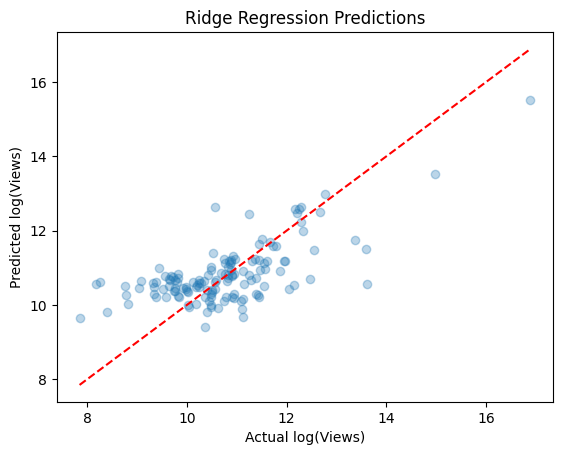

In [46]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_test_pred_ridge, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual log(Views)")
plt.ylabel("Predicted log(Views)")
plt.title("Ridge Regression Predictions")
plt.show()
